# Aggregation Metric Evaluation — L9 MCTS (first 30 cases)

For each log file:
1. Extract ALL Python scripts embedded in the log
2. Run each script to produce an output CSV
3. Score with `relative_csv_score` (FD + column map)
4. Also score with L1, L2, KL Divergence, EMD, JS Distance
   - Sort both predicted and ground truth columns, take 100 uniform samples, compare
   - similarity = 1 − distance

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, re, glob, sys, subprocess, tempfile
import warnings
warnings.filterwarnings('ignore')

WORK_DIR  = '/home/asurite.ad.asu.edu/jrtandel/transchema/'
LOG_DIR   = WORK_DIR + 'logs_langraph/mcts_github_partial_l9_41mini/'
PIPE_DIR  = WORK_DIR + 'autopipeline-benchmarks/github-pipelines/'
N_SAMPLES = 100   # uniform samples after sorting for distribution metrics
CASE_RANGE = range(1, 11)  # 9_1 to 9_10

sys.path.insert(0, WORK_DIR)
from eval_score.score import relative_csv_score

print(f'Evaluating cases: 9_{CASE_RANGE.start} to 9_{CASE_RANGE.stop - 1}')

Evaluating cases: 9_1 to 9_10


In [54]:
# --------------------------------------------------------------------------
# Parse log files — only cases in CASE_RANGE
# --------------------------------------------------------------------------

def parse_log(log_path):
    with open(log_path) as f:
        text = f.read()
    m = re.search(r'Starting task: Target9_(\d+)', text)
    case_id = int(m.group(1)) if m else None
    m = re.search(r'\[MCTS Complete\].*best_score=([0-9.]+)', text)
    best_score = float(m.group(1)) if m else None
    scripts = re.findall(r'```[Pp]ython\n(.*?)```', text, re.DOTALL)
    return case_id, best_score, scripts


log_files = sorted(
    glob.glob(LOG_DIR + '9_target*_MCTS_*.log'),
    key=lambda p: int(re.search(r'9_target(\d+)_MCTS', p).group(1))
)

cases = []
for lf in log_files:
    case_id, best_score, scripts = parse_log(lf)
    if case_id is None or case_id not in CASE_RANGE:
        continue
    if not scripts:
        print(f'  9_{case_id}: no scripts found — skipped')
        continue
    gt_path = os.path.join(PIPE_DIR, f'length9_{case_id}', 'target.csv')
    if not os.path.exists(gt_path):
        print(f'  9_{case_id}: ground truth missing — skipped')
        continue
    cases.append({'case_id': case_id, 'mcts_score': best_score,
                  'scripts': scripts, 'gt_path': gt_path})

print(f'Loaded {len(cases)} cases, total scripts: {sum(len(c["scripts"]) for c in cases)}')
for c in cases:
    print(f"  9_{c['case_id']:3d} | mcts={c['mcts_score']} | scripts={len(c['scripts'])}")

Loaded 10 cases, total scripts: 73
  9_  1 | mcts=0.0 | scripts=20
  9_  2 | mcts=1.0 | scripts=1
  9_  3 | mcts=0.0 | scripts=20
  9_  4 | mcts=0.0 | scripts=20
  9_  5 | mcts=1.0 | scripts=1
  9_  6 | mcts=1.0 | scripts=4
  9_  7 | mcts=1.0 | scripts=1
  9_  8 | mcts=1.0 | scripts=1
  9_  9 | mcts=1.0 | scripts=1
  9_ 10 | mcts=1.0 | scripts=4


In [55]:
# --------------------------------------------------------------------------
# Run a python script, return output DataFrame or None on failure
# Scripts use relative paths — run from WORK_DIR
# --------------------------------------------------------------------------

def run_script(script_code, work_dir=WORK_DIR, timeout=30):
    """Write script to a temp file, execute it, return output CSV path."""
    # find the output path from the script (to_csv call)
    m = re.search(r'\.to_csv\(["\']([^"\'\']+)["\']', script_code)
    if not m:
        return None
    rel_out = m.group(1)
    abs_out = os.path.join(work_dir, rel_out)

    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as tf:
        tf.write(script_code)
        tmp_path = tf.name

    try:
        result = subprocess.run(
            [sys.executable, tmp_path],
            cwd=work_dir, capture_output=True, text=True, timeout=timeout
        )
        if result.returncode != 0 or not os.path.exists(abs_out):
            return None
        df = pd.read_csv(abs_out)
        return df
    except Exception:
        return None
    finally:
        os.unlink(tmp_path)

print('run_script() defined.')

run_script() defined.


In [56]:
# --------------------------------------------------------------------------
# Distribution metrics — each (pred_col, gt_col) pair normalizes independently
# Uses N_SAMPLES uniform samples from sorted arrays for comparison
# Returns similarity = 1 - distance
# --------------------------------------------------------------------------

def uniform_sample(arr, n=N_SAMPLES):
    """Sort arr, take n evenly-spaced samples."""
    arr_s = np.sort(arr.astype(float))  # cast to float to prevent int64 overflow in L2
    idx   = np.linspace(0, len(arr_s) - 1, n).astype(int)
    return arr_s[idx]

def to_prob_shared(a, b):
    bins = max(2, int(np.ceil(np.log2(len(a)) + 1)))
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    if lo == hi:
        return np.array([1.0]), np.array([1.0])
    pa, _ = np.histogram(a, bins=bins, range=(lo, hi))
    pb, _ = np.histogram(b, bins=bins, range=(lo, hi))
    pa = pa.astype(float) + 1e-10
    pb = pb.astype(float) + 1e-10
    return pa / pa.sum(), pb / pb.sum()

def pair_range(a, b):
    lo, hi = min(a.min(), b.min()), max(a.max(), b.max())
    return (hi - lo) if hi > lo else 1.0

def dist_l1(a, b):  return np.mean(np.abs(a - b)) / pair_range(a, b)
def dist_l2(a, b):  return np.sqrt(np.mean((a - b) ** 2)) / pair_range(a, b)

def dist_emd(a, b):
    from scipy.stats import wasserstein_distance
    return wasserstein_distance(a, b) / pair_range(a, b)

def dist_kl(a, b):
    from scipy.stats import entropy
    pa, pb = to_prob_shared(a, b)
    return 1 - np.exp(-entropy(pa, pb))

def dist_js(a, b):
    from scipy.spatial.distance import jensenshannon
    pa, pb = to_prob_shared(a, b)
    return float(jensenshannon(pa, pb, base=2))

DIST_METRICS = {'L1': dist_l1, 'L2': dist_l2,
                'KL': dist_kl, 'EMD': dist_emd, 'JS': dist_js}


def distribution_similarity(df_pred, df_gt, n_samples=N_SAMPLES):
    """
    For each shared numeric column:
      - sort both arrays, take n_samples uniform samples
      - compute each distance metric → similarity = 1 - distance
    Returns dict: metric → mean similarity across columns
    """
    pred_num = {c.lower(): c for c in df_pred.select_dtypes(include='number').columns}
    gt_num   = {c.lower(): c for c in df_gt.select_dtypes(include='number').columns}
    shared   = sorted(pred_num.keys() & gt_num.keys())

    if not shared:
        return {m: None for m in DIST_METRICS}

    col_scores = {m: [] for m in DIST_METRICS}

    for col in shared:
        a = pd.to_numeric(df_pred[pred_num[col]], errors='coerce').dropna().values
        b = pd.to_numeric(df_gt[gt_num[col]],     errors='coerce').dropna().values
        if len(a) < 2 or len(b) < 2:
            continue
        a_s = uniform_sample(a, n_samples)
        b_s = uniform_sample(b, n_samples)
        for m, fn in DIST_METRICS.items():
            col_scores[m].append(fn(a_s, b_s))

    return {
        m: round(1 - np.mean(v), 4) if v else None
        for m, v in col_scores.items()
    }

print(f'Distribution metrics defined. Using {N_SAMPLES} uniform samples per column.')

Distribution metrics defined. Using 100 uniform samples per column.


In [57]:
# --------------------------------------------------------------------------
# Evaluate all cases: run every script, score with eval_score + dist metrics
# Only numerical columns are used for all scoring
# --------------------------------------------------------------------------

def numeric_only(df):
    """Return DataFrame with only numerical columns."""
    return df.select_dtypes(include='number')

all_results = []  # one row per (case, script)

for c in cases:
    case_id    = c['case_id']
    mcts_score = c['mcts_score']
    gt_num     = numeric_only(pd.read_csv(c['gt_path']))

    if gt_num.empty:
        print(f'  9_{case_id}: no numeric columns in ground truth — skipped')
        continue

    for s_idx, script in enumerate(c['scripts']):
        pred = run_script(script)

        if pred is None:
            print(f'  9_{case_id} script {s_idx}: execution failed')
            all_results.append({'case_id': case_id, 'script_idx': s_idx,
                                 'mcts_score': mcts_score, 'valid': False,
                                 'eval_score': None, 'fd_f1': None, 'col_ratio': None,
                                 **{m: None for m in DIST_METRICS}})
            continue

        pred_num = numeric_only(pred)

        if pred_num.empty:
            print(f'  9_{case_id} script {s_idx}: no numeric columns in output — skipped')
            all_results.append({'case_id': case_id, 'script_idx': s_idx,
                                 'mcts_score': mcts_score, 'valid': False,
                                 'eval_score': None, 'fd_f1': None, 'col_ratio': None,
                                 **{m: None for m in DIST_METRICS}})
            continue

        # eval_score on numeric columns only
        try:
            _, col_ratio, _, fd_f1, eval_sc, _ = relative_csv_score(pred_num, gt_num)
        except Exception as e:
            print(f'  9_{case_id} script {s_idx}: eval_score failed — {e}')
            eval_sc = col_ratio = fd_f1 = None

        # distribution metrics on numeric columns only
        dist_sims = distribution_similarity(pred_num, gt_num)

        row = {'case_id': case_id, 'script_idx': s_idx,
               'mcts_score': mcts_score, 'valid': True,
               'eval_score': eval_sc, 'fd_f1': fd_f1, 'col_ratio': col_ratio,
               **dist_sims}
        all_results.append(row)
        print(f'  9_{case_id} s{s_idx} | eval={eval_sc:.3f} | '
              + ' '.join(f'{m}={dist_sims[m]:.3f}' if dist_sims[m] is not None else f'{m}=None'
                         for m in DIST_METRICS))

df_all = pd.DataFrame(all_results)
print(f'\nTotal rows: {len(df_all)}  |  Valid: {df_all["valid"].sum()}')

get column map
get column map
  9_1 s0 | eval=0.333 | L1=0.960 L2=0.887 KL=0.787 EMD=0.960 JS=0.777
get column map
get column map
  9_1 s1 | eval=0.333 | L1=0.960 L2=0.887 KL=0.787 EMD=0.960 JS=0.777
  9_1 script 2: execution failed
get column map
get column map
  9_1 s3 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
get column map
get column map
  9_1 s4 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
get column map
get column map
  9_1 s5 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
  9_1 script 6: execution failed
get column map
get column map
  9_1 s7 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
get column map
get column map
  9_1 s8 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
get column map
get column map
  9_1 s9 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777
  9_1 script 10: execution failed
get column map
get column map
  9_1 s11 | eval=0.333 | L1=0.962 L2=0.907 KL=0.787 EMD=0.962 JS=0.777

In [58]:
# Keep only valid scripts and split into correct vs incorrect
df = df_all[df_all['valid']].copy()

# Base score cols (drop col_ratio)
base_cols = ['eval_score', 'fd_f1'] + list(DIST_METRICS.keys())

# Add combination columns: (fd_f1 + dist) / 2 and (eval_score + dist) / 2
for m in DIST_METRICS.keys():
    df[f'fd_f1+{m}']     = df[['fd_f1',     m]].mean(axis=1)
    df[f'eval+{m}']      = df[['eval_score', m]].mean(axis=1)

combo_fd   = [f'fd_f1+{m}'  for m in DIST_METRICS.keys()]
combo_eval = [f'eval+{m}'   for m in DIST_METRICS.keys()]
score_cols = base_cols + combo_fd + combo_eval

df_correct   = df[df['mcts_score'] == 1.0]
df_incorrect = df[df['mcts_score'] == 0.0]
df_partial   = df[(df['mcts_score'] > 0.0) & (df['mcts_score'] < 1.0)]

print(f'Total valid scripts : {len(df)}')
print(f'  Correct (score=1) : {len(df_correct)}')
print(f'  Incorrect (score=0): {len(df_incorrect)}')
print(f'  Partial (0<score<1): {len(df_partial)}')
print()
print('Mean scores for INCORRECT scripts (score=0):')
print(df_incorrect[score_cols].mean().round(4).to_string())
print()
print('Mean scores for CORRECT scripts (score=1):')
print(df_correct[score_cols].mean().round(4).to_string())

Total valid scripts : 56
  Correct (score=1) : 11
  Incorrect (score=0): 45
  Partial (0<score<1): 0

Mean scores for INCORRECT scripts (score=0):
eval_score    0.5556
fd_f1         0.3333
L1            0.9693
L2            0.9225
KL            0.8246
EMD           0.9693
JS            0.8326
fd_f1+L1      0.6513
fd_f1+L2      0.6279
fd_f1+KL      0.5790
fd_f1+EMD     0.6513
fd_f1+JS      0.5830
eval+L1       0.7624
eval+L2       0.7390
eval+KL       0.6901
eval+EMD      0.7624
eval+JS       0.6941

Mean scores for CORRECT scripts (score=1):
eval_score    0.7455
fd_f1         0.7818
L1            0.9924
L2            0.9898
KL            0.9906
EMD           0.9924
JS            0.9730
fd_f1+L1      0.8871
fd_f1+L2      0.8858
fd_f1+KL      0.8862
fd_f1+EMD     0.8871
fd_f1+JS      0.8774
eval+L1       0.8689
eval+L2       0.8676
eval+KL       0.8680
eval+EMD      0.8689
eval+JS       0.8592


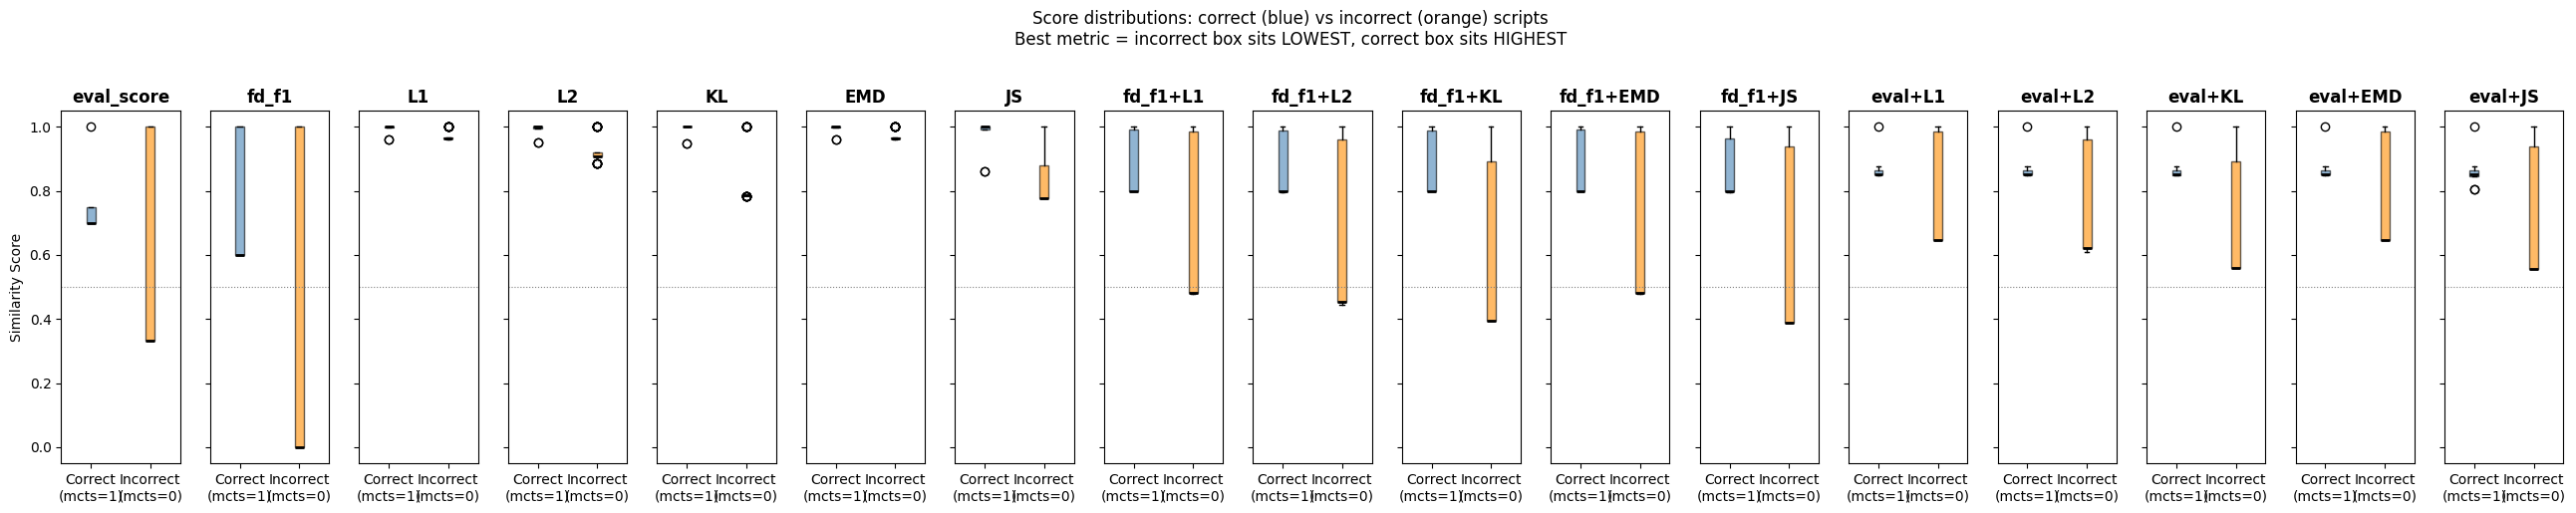

In [59]:
# --------------------------------------------------------------------------
# Plot 1: score distributions for correct vs incorrect scripts
# Box plot per metric — we want incorrect scripts (orange) to sit LOW
# --------------------------------------------------------------------------

fig, axes = plt.subplots(1, len(score_cols), figsize=(26, 5), sharey=True)

for idx, col in enumerate(score_cols):
    ax = axes[idx]
    data_correct   = df_correct[col].dropna()
    data_incorrect = df_incorrect[col].dropna()

    ax.boxplot(
        [data_correct, data_incorrect],
        labels=['Correct\n(mcts=1)', 'Incorrect\n(mcts=0)'],
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='black', linewidth=2),
    )
    # colour incorrect box orange
    boxes = ax.patches
    if len(boxes) >= 2:
        boxes[1].set_facecolor('darkorange')

    ax.set_title(col, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)

axes[0].set_ylabel('Similarity Score')
plt.suptitle(
    'Score distributions: correct (blue) vs incorrect (orange) scripts\n'
    'Best metric = incorrect box sits LOWEST, correct box sits HIGHEST',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig('eval_bad_code_detection.png', dpi=150, bbox_inches='tight')
plt.show()

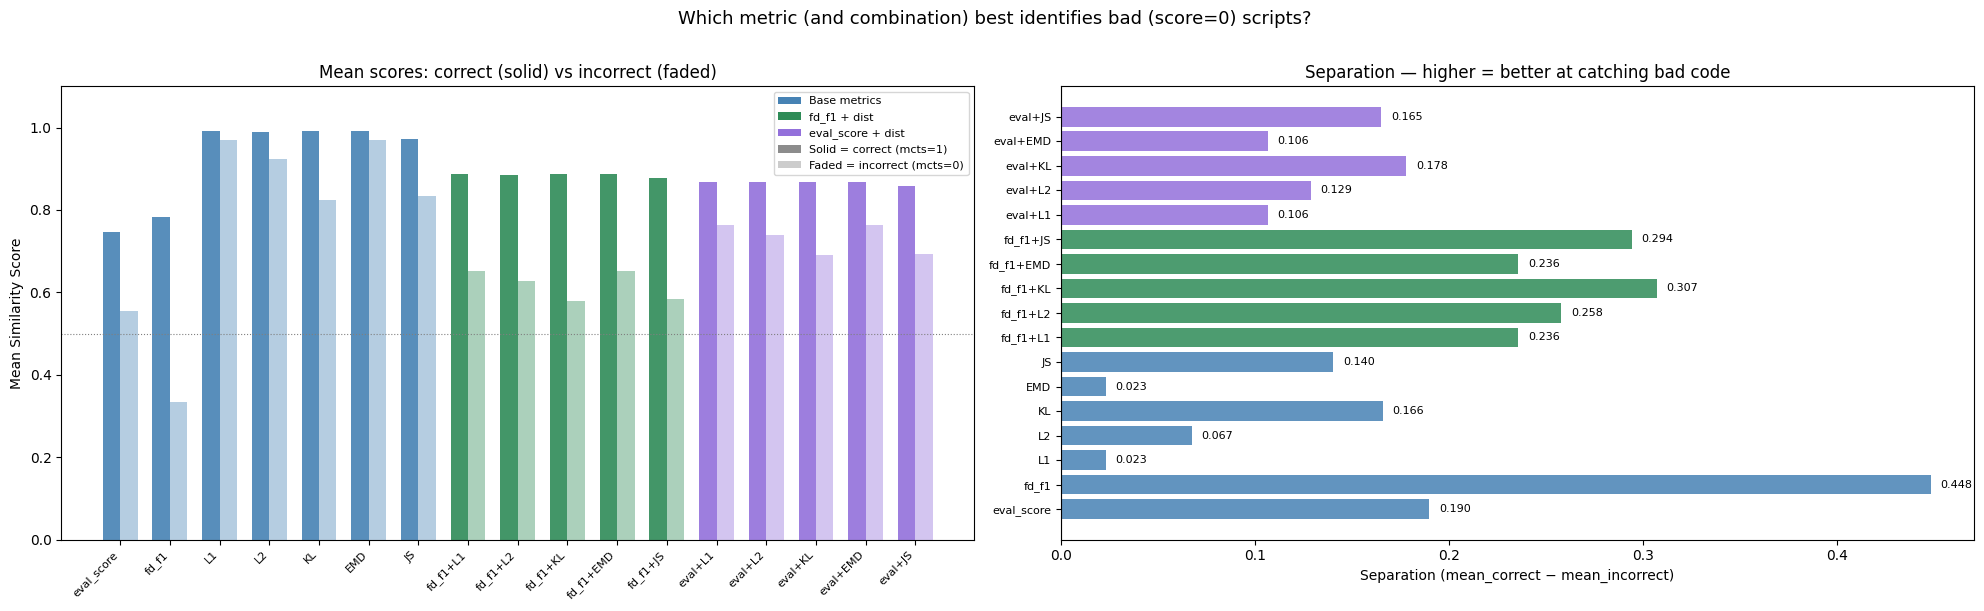


Separation ranking (best → worst):
  Metric               Score on bad  Score on good  Separation
  ------------------------------------------------------------
  fd_f1                      0.3333         0.7818      0.4485
  fd_f1+KL                   0.5790         0.8862      0.3073
  fd_f1+JS                   0.5830         0.8774      0.2944
  fd_f1+L2                   0.6279         0.8858      0.2579
  fd_f1+L1                   0.6513         0.8871      0.2358
  fd_f1+EMD                  0.6513         0.8871      0.2358
  eval_score                 0.5556         0.7455      0.1899
  eval+KL                    0.6901         0.8680      0.1780
  KL                         0.8246         0.9906      0.1660
  eval+JS                    0.6941         0.8592      0.1651
  JS                         0.8326         0.9730      0.1403
  eval+L2                    0.7390         0.8676      0.1286
  eval+L1                    0.7624         0.8689      0.1065
  eval+EMD         

In [60]:
# --------------------------------------------------------------------------
# Separation analysis — grouped bar chart with 3 groups:
#   1. Base metrics (eval_score, fd_f1, L1, L2, KL, EMD, JS)
#   2. fd_f1 + distribution combos
#   3. eval_score + distribution combos
# --------------------------------------------------------------------------

sep = {}
for col in score_cols:
    mc = df_correct[col].dropna().mean()
    mi = df_incorrect[col].dropna().mean()
    sep[col] = {'mean_correct': mc, 'mean_incorrect': mi, 'separation': mc - mi}

sep_df = pd.DataFrame(sep).T

# Split into 3 groups for plotting
groups = {
    'Base metrics':        base_cols,
    'fd_f1 + dist':        combo_fd,
    'eval_score + dist':   combo_eval,
}
colors = {'Base metrics': 'steelblue', 'fd_f1 + dist': 'seagreen', 'eval_score + dist': 'mediumpurple'}

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- Left: mean correct vs incorrect bars per metric ---
all_cols_ordered = base_cols + combo_fd + combo_eval
x = np.arange(len(all_cols_ordered))
w = 0.35

bar_colors = []
for col in all_cols_ordered:
    for grp, cols in groups.items():
        if col in cols:
            bar_colors.append(colors[grp])
            break

axes[0].bar(x - w/2, [sep[c]['mean_correct']   for c in all_cols_ordered],
            w, color=bar_colors, alpha=0.9, label='_nolegend_')
axes[0].bar(x + w/2, [sep[c]['mean_incorrect']  for c in all_cols_ordered],
            w, color=bar_colors, alpha=0.4, label='_nolegend_')

# legend: solid = correct, faded = incorrect + group colours
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=colors[g], label=g) for g in groups]
legend_els += [Patch(facecolor='gray', alpha=0.9, label='Solid = correct (mcts=1)'),
               Patch(facecolor='gray', alpha=0.4, label='Faded = incorrect (mcts=0)')]
axes[0].legend(handles=legend_els, fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_cols_ordered, rotation=45, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Mean Similarity Score')
axes[0].set_title('Mean scores: correct (solid) vs incorrect (faded)')
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=0.8)

# --- Right: separation bars ---
sep_vals = [sep[c]['separation'] for c in all_cols_ordered]
bars = axes[1].barh(all_cols_ordered, sep_vals, color=bar_colors, alpha=0.85)
axes[1].set_xlabel('Separation (mean_correct − mean_incorrect)')
axes[1].set_title('Separation — higher = better at catching bad code')
axes[1].axvline(0, color='gray', linewidth=0.8)
for i, v in enumerate(sep_vals):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('Which metric (and combination) best identifies bad (score=0) scripts?',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('eval_separation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSeparation ranking (best → worst):')
sep_sorted = sorted(sep.items(), key=lambda x: x[1]['separation'], reverse=True)
print(f'  {"Metric":<20} {"Score on bad":>12} {"Score on good":>14} {"Separation":>11}')
print('  ' + '-' * 60)
for col, row in sep_sorted:
    print(f'  {col:<20} {row["mean_incorrect"]:>12.4f} {row["mean_correct"]:>14.4f} {row["separation"]:>11.4f}')

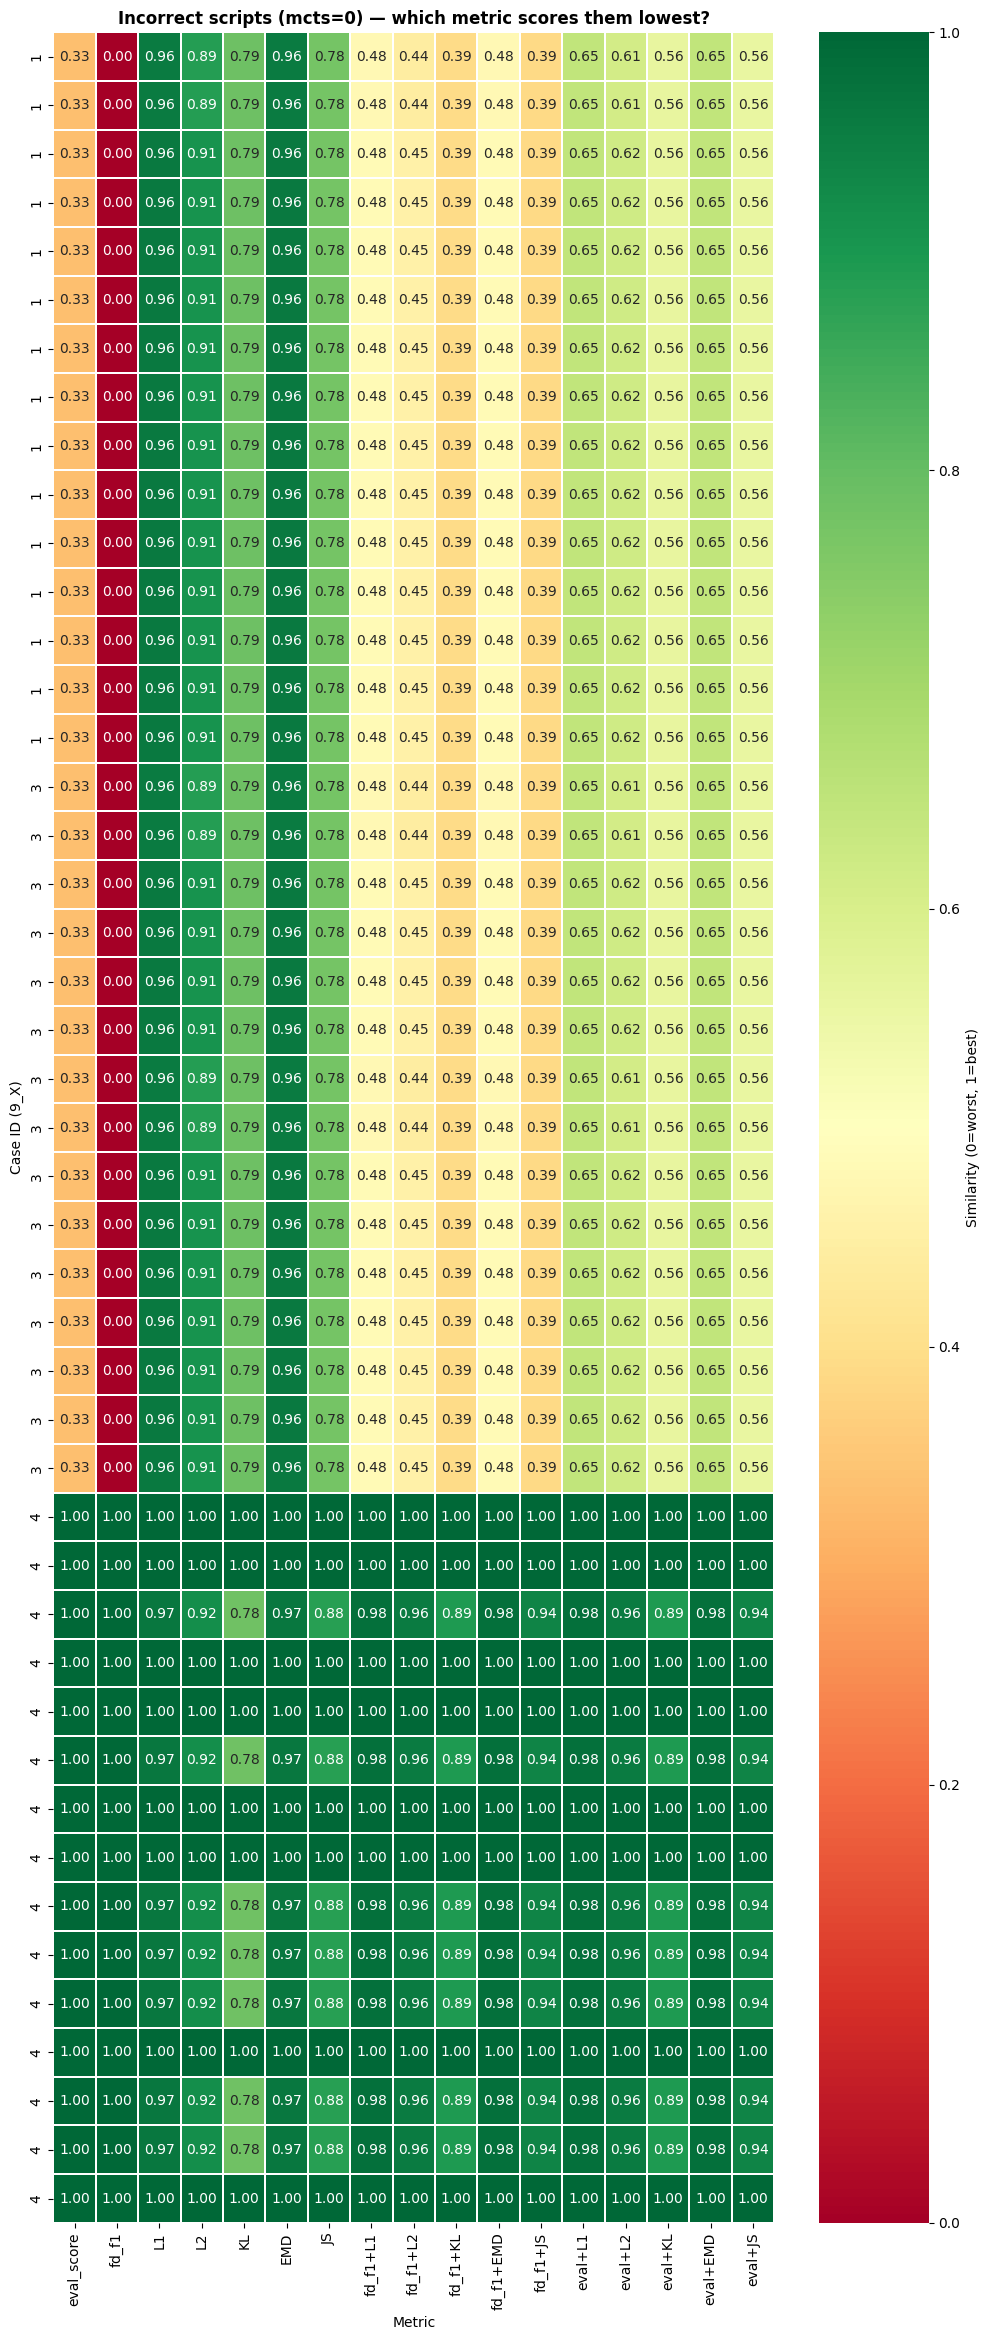

In [61]:
# --------------------------------------------------------------------------
# Heatmap: scores for each INCORRECT script across all metrics
# We want to see which metric scores bad scripts lowest
# --------------------------------------------------------------------------

if not df_incorrect.empty:
    heat_cols = score_cols
    heat_df   = df_incorrect.set_index('case_id')[heat_cols]

    fig, ax = plt.subplots(figsize=(10, max(4, len(heat_df) * 0.5 + 1)))
    sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='RdYlGn',
                ax=ax, linewidths=0.3, vmin=0, vmax=1,
                cbar_kws={'label': 'Similarity (0=worst, 1=best)'})
    ax.set_title('Incorrect scripts (mcts=0) — which metric scores them lowest?',
                 fontweight='bold')
    ax.set_xlabel('Metric')
    ax.set_ylabel('Case ID (9_X)')
    plt.tight_layout()
    plt.savefig('eval_incorrect_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No incorrect (mcts=0) scripts found in this range.')

In [62]:
# --------------------------------------------------------------------------
# Final ranking summary
# --------------------------------------------------------------------------

print('METRIC RANKING — ability to detect bad code (mcts=0)\n')
print(f'  {"Metric":<15} {"Score on bad":>12} {"Score on good":>14} {"Separation":>11}')
print('  ' + '-' * 55)
for metric, row in sep_df.iterrows():
    print(f'  {metric:<15} {row["mean_incorrect"]:>12.4f} {row["mean_correct"]:>14.4f} {row["separation"]:>11.4f}')

print('\nConclusion: metric with LOWEST "Score on bad" and HIGHEST "Separation" is best.')

METRIC RANKING — ability to detect bad code (mcts=0)

  Metric          Score on bad  Score on good  Separation
  -------------------------------------------------------
  eval_score            0.5556         0.7455      0.1899
  fd_f1                 0.3333         0.7818      0.4485
  L1                    0.9693         0.9924      0.0231
  L2                    0.9225         0.9898      0.0674
  KL                    0.8246         0.9906      0.1660
  EMD                   0.9693         0.9924      0.0231
  JS                    0.8326         0.9730      0.1403
  fd_f1+L1              0.6513         0.8871      0.2358
  fd_f1+L2              0.6279         0.8858      0.2579
  fd_f1+KL              0.5790         0.8862      0.3073
  fd_f1+EMD             0.6513         0.8871      0.2358
  fd_f1+JS              0.5830         0.8774      0.2944
  eval+L1               0.7624         0.8689      0.1065
  eval+L2               0.7390         0.8676      0.1286
  eval+KL         